# Global YouTube Statistics — Análise Exploratória

Base com **995 canais** e **28 variáveis** cobrindo métricas de engajamento, monetização e dados demográficos por país.

In [1]:
import warnings
import pathlib
import io

import matplotlib
matplotlib.use('Agg')

import chardet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from IPython.display import display, Image

def _show_inline(*args, **kwargs):
    for num in plt.get_fignums():
        buf = io.BytesIO()
        plt.figure(num).savefig(buf, format='png', bbox_inches='tight', dpi=100)
        buf.seek(0)
        display(Image(data=buf.read()))
    plt.close('all')

plt.show = _show_inline

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid', palette='muted')

In [2]:
def _detect_encoding(path):
    with open(path, 'rb') as f:
        return chardet.detect(f.read(100000))['encoding']

_csv_name = 'Global YouTube Statistics.csv'
_csv_path = next(
    (p for p in [pathlib.Path(_csv_name), pathlib.Path.cwd() / _csv_name] if p.exists()),
    None
)

if _csv_path is None:
    try:
        from google.colab import files
        _uploaded = files.upload()
        _csv_path = pathlib.Path(next(iter(_uploaded)))
    except ImportError:
        raise FileNotFoundError(f'{_csv_name} não encontrado. Coloque o CSV na mesma pasta do notebook.')

df = pd.read_csv(_csv_path, encoding=_detect_encoding(_csv_path))
df.head()

Saving Global YouTube Statistics.csv to Global YouTube Statistics.csv


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,1.0,1.0,1.0,2.258000e+09,564600.0,9000000.00,6800000.00,1.084000e+08,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,4055159.0,7670.0,7423.0,1.200000e+01,0.0,0.05,0.04,5.800000e-01,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,48.0,1.0,1.0,1.348000e+09,337000.0,5400000.00,4000000.00,6.470000e+07,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,2.0,2.0,1.0,1.975000e+09,493800.0,7900000.00,5900000.00,9.480000e+07,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,3.0,2.0,2.0,1.824000e+09,455900.0,7300000.00,5500000.00,8.750000e+07,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


## 1. Exploração Inicial

In [3]:
print(f'Shape: {df.shape}')
print(f'\nTipos de dados:\n{df.dtypes.to_string()}')
df.head(10)

Shape: (995, 28)

Tipos de dados:
rank                                         int64
Youtuber                                    object
subscribers                                  int64
video views                                float64
category                                    object
Title                                       object
uploads                                      int64
Country                                     object
Abbreviation                                object
channel_type                                object
video_views_rank                           float64
country_rank                               float64
channel_type_rank                          float64
video_views_for_the_last_30_days           float64
lowest_monthly_earnings                    float64
highest_monthly_earnings                   float64
lowest_yearly_earnings                     float64
highest_yearly_earnings                    float64
subscribers_for_last_30_days               float

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,1.0,1.0,1.0,2.258000e+09,564600.0,9000000.00,6800000.00,1.084000e+08,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,4055159.0,7670.0,7423.0,1.200000e+01,0.0,0.05,0.04,5.800000e-01,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,48.0,1.0,1.0,1.348000e+09,337000.0,5400000.00,4000000.00,6.470000e+07,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,2.0,2.0,1.0,1.975000e+09,493800.0,7900000.00,5900000.00,9.480000e+07,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,3.0,2.0,2.0,1.824000e+09,455900.0,7300000.00,5500000.00,8.750000e+07,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
5,6,Music,119000000,0.000000e+00,NaN,Music,0,NaN,NaN,Music,4057944.0,NaN,NaN,NaN,0.0,0.00,0.00,0.000000e+00,NaN,2013.0,Sep,24.0,NaN,NaN,NaN,NaN,NaN,NaN
6,7,ýýý Kids Diana Show,112000000,9.324704e+10,People & Blogs,ýýý Kids Diana Show,1111,United States,US,Entertainment,5.0,3.0,3.0,7.316740e+08,182900.0,2900000.00,2200000.00,3.510000e+07,NaN,2015.0,May,12.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
7,8,PewDiePie,111000000,2.905804e+10,Gaming,PewDiePie,4716,Japan,JP,Entertainment,44.0,1.0,4.0,3.918400e+07,9800.0,156700.00,117600.00,1.900000e+06,NaN,2010.0,Apr,29.0,63.2,1.262266e+08,2.29,115782416.0,36.204824,138.252924
8,9,Like Nastya,106000000,9.047906e+10,People & Blogs,Like Nastya Vlog,493,Russia,RU,People,630.0,5.0,25.0,4.894700e+07,12200.0,195800.00,146800.00,2.300000e+06,100000.0,2016.0,Jan,14.0,81.9,1.443735e+08,4.59,107683889.0,61.524010,105.318756
9,10,Vlad and Niki,98900000,7.718017e+10,Entertainment,Vlad and Niki,574,United States,US,Entertainment,8.0,5.0,6.0,5.805740e+08,145100.0,2300000.00,1700000.00,2.790000e+07,600000.0,2018.0,Apr,23.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rank,995.0,NaN,NaN,NaN,498.0,287.37606,1.0,249.5,498.0,746.5,995.0
Youtuber,995,995,Make Joke Of,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscribers,995.0,NaN,NaN,NaN,22982412.060302,17526105.340936,12300000.0,14500000.0,17700000.0,24600000.0,245000000.0
video views,995.0,NaN,NaN,NaN,11039537052.038191,14110844376.829655,0.0,4288145410.0,7760819588.0,13554701853.0,228000000000.0
category,949,18,Entertainment,241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,995,992,Preston,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uploads,995.0,NaN,NaN,NaN,9187.125628,34151.352254,0.0,194.5,729.0,2667.5,301308.0
Country,873,49,United States,313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Abbreviation,873,49,US,313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_type,965,14,Entertainment,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing = pd.DataFrame({
    'faltantes': df.isnull().sum(),
    'percentual (%)': (df.isnull().mean() * 100).round(2)
}).query('faltantes > 0').sort_values('faltantes', ascending=False)

missing

,faltantes,percentual (%)
subscribers_for_last_30_days,337,33.87
Urban_population,123,12.36
Unemployment rate,123,12.36
Population,123,12.36
Longitude,123,12.36
Latitude,123,12.36
Gross tertiary education enrollment (%),123,12.36
Country,122,12.26
Abbreviation,122,12.26
country_rank,116,11.66


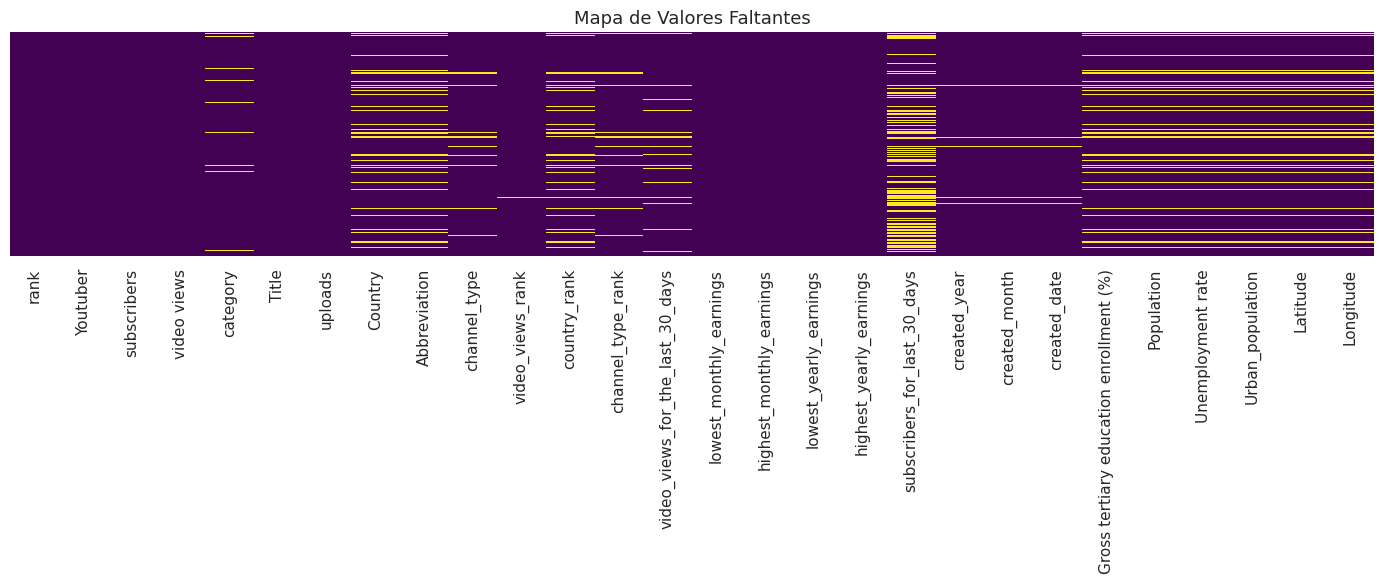

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Mapa de Valores Faltantes', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Análise Exploratória de Dados

Correlações calculadas pelo método de **Spearman** — mais adequado para distribuições assimétricas e relações monotônicas não-lineares, como as encontradas em métricas de engajamento e monetização.

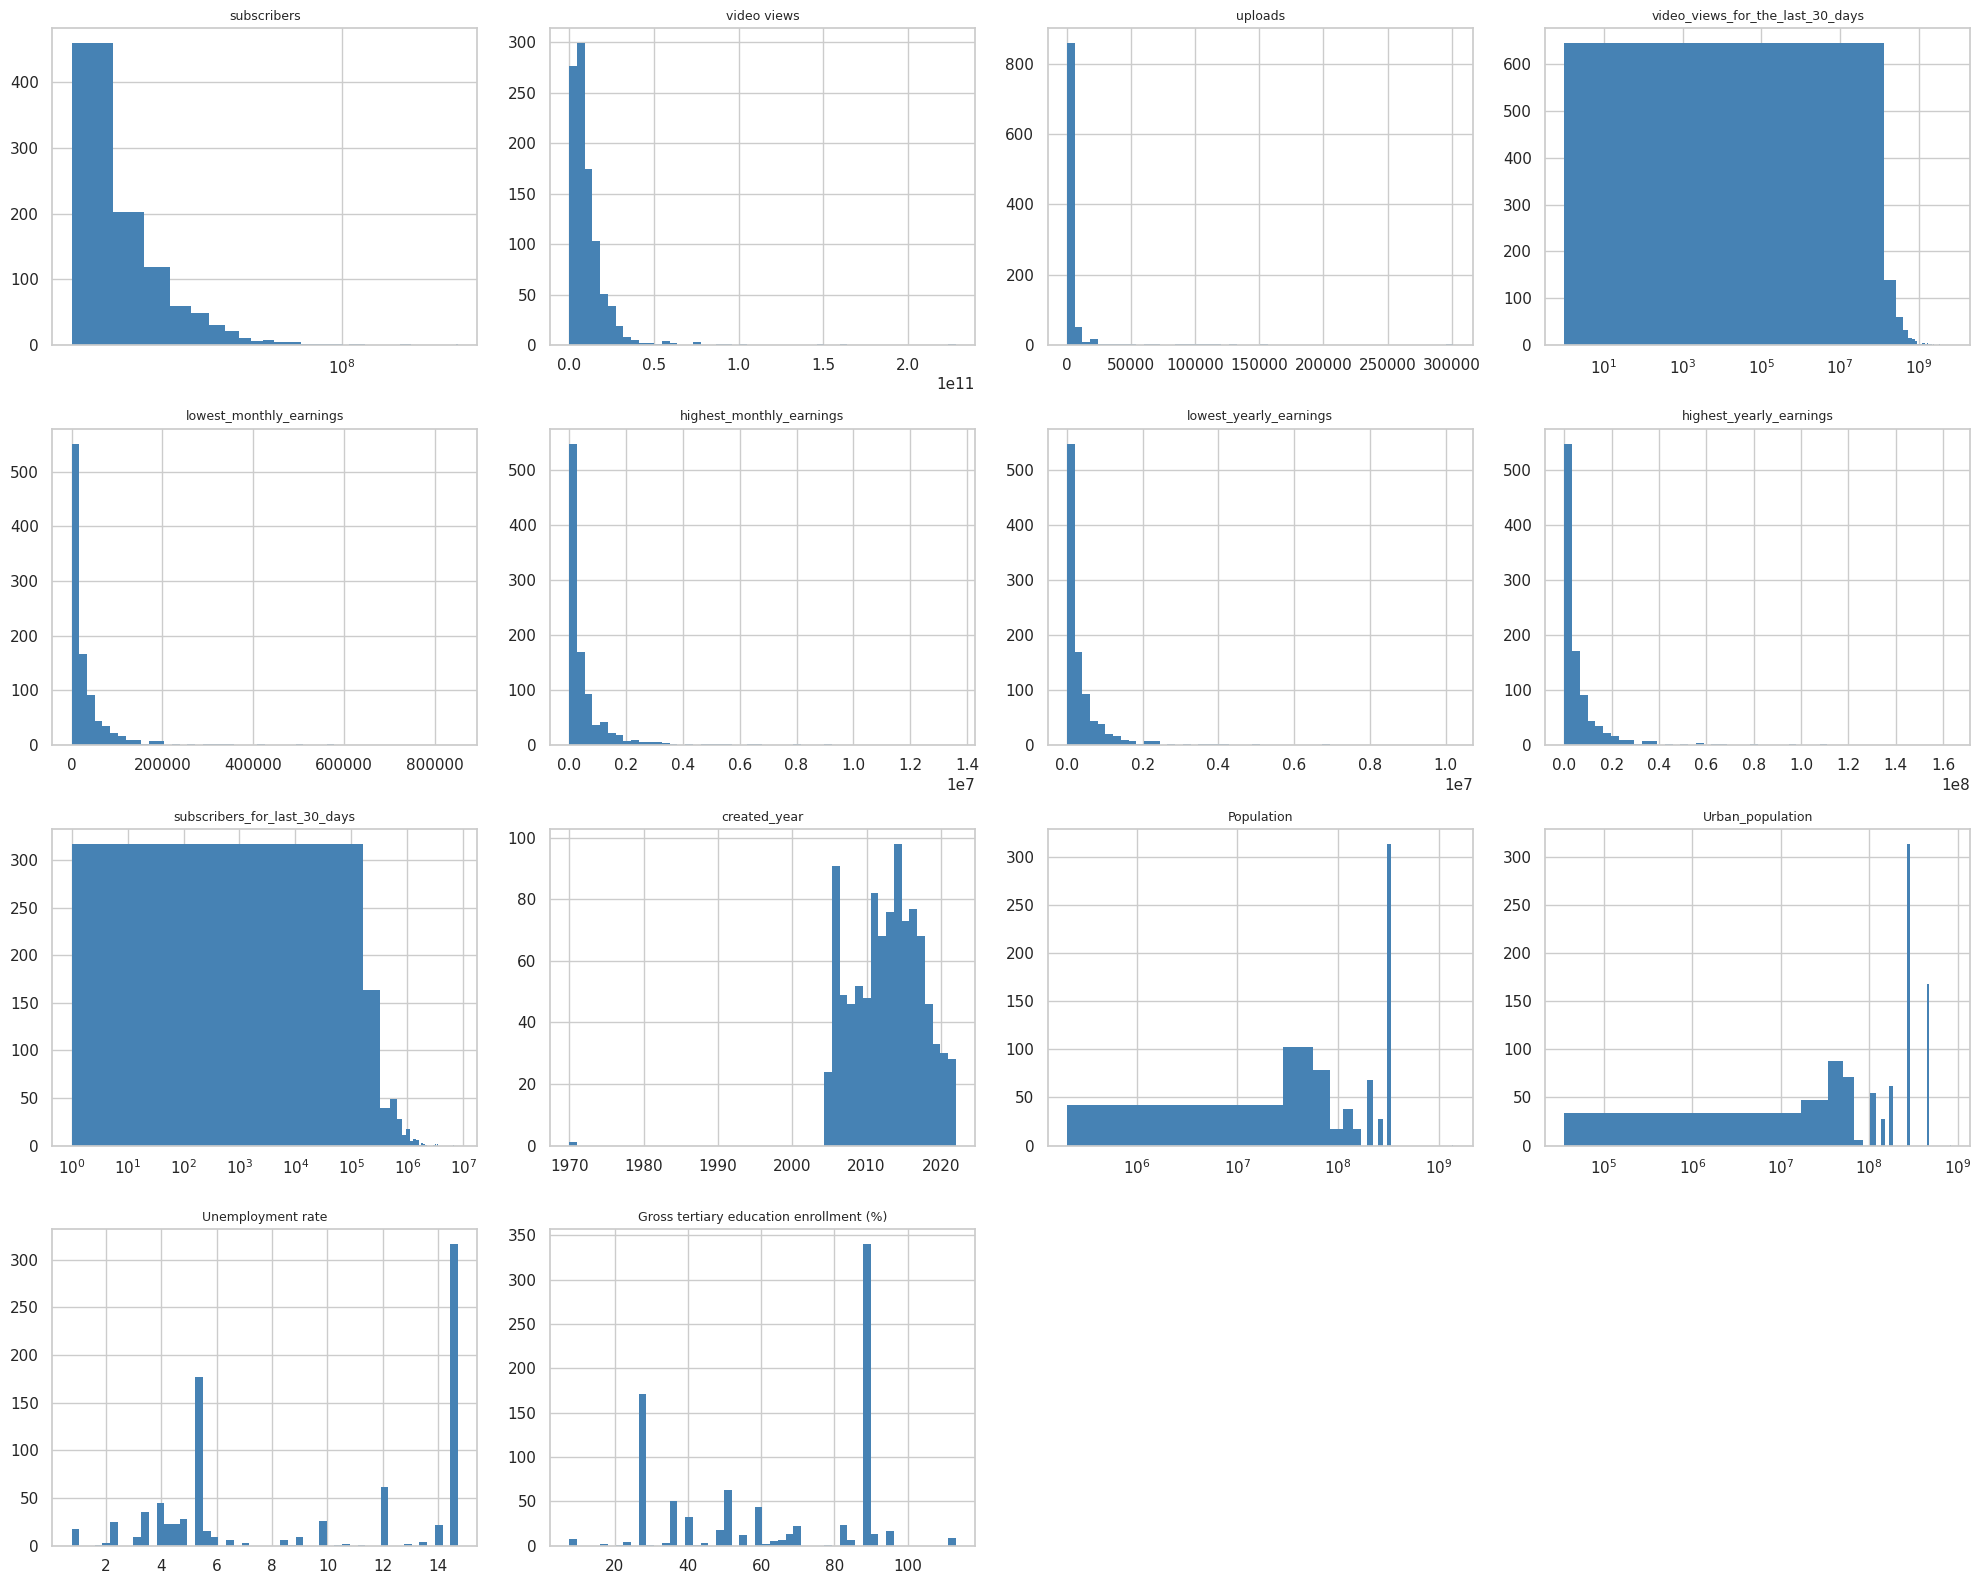

In [7]:
SKEWED_COLS = {
    'subscribers', 'video views', 'uploads',
    'lowest_monthly_earnings', 'highest_monthly_earnings',
    'lowest_yearly_earnings', 'highest_yearly_earnings',
    'subscribers_for_last_30_days', 'video_views_for_the_last_30_days',
    'Population', 'Urban_population',
}

HIST_COLS = [
    'subscribers', 'video views', 'uploads',
    'video_views_for_the_last_30_days',
    'lowest_monthly_earnings', 'highest_monthly_earnings',
    'lowest_yearly_earnings', 'highest_yearly_earnings',
    'subscribers_for_last_30_days', 'created_year',
    'Population', 'Urban_population',
    'Unemployment rate', 'Gross tertiary education enrollment (%)',
]

n_cols = 4
n_rows = -(-len(HIST_COLS) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(HIST_COLS):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='none')
    ax.set_title(col, fontsize=9)
    if col in SKEWED_COLS and (data > 0).all():
        ax.set_xscale('log')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

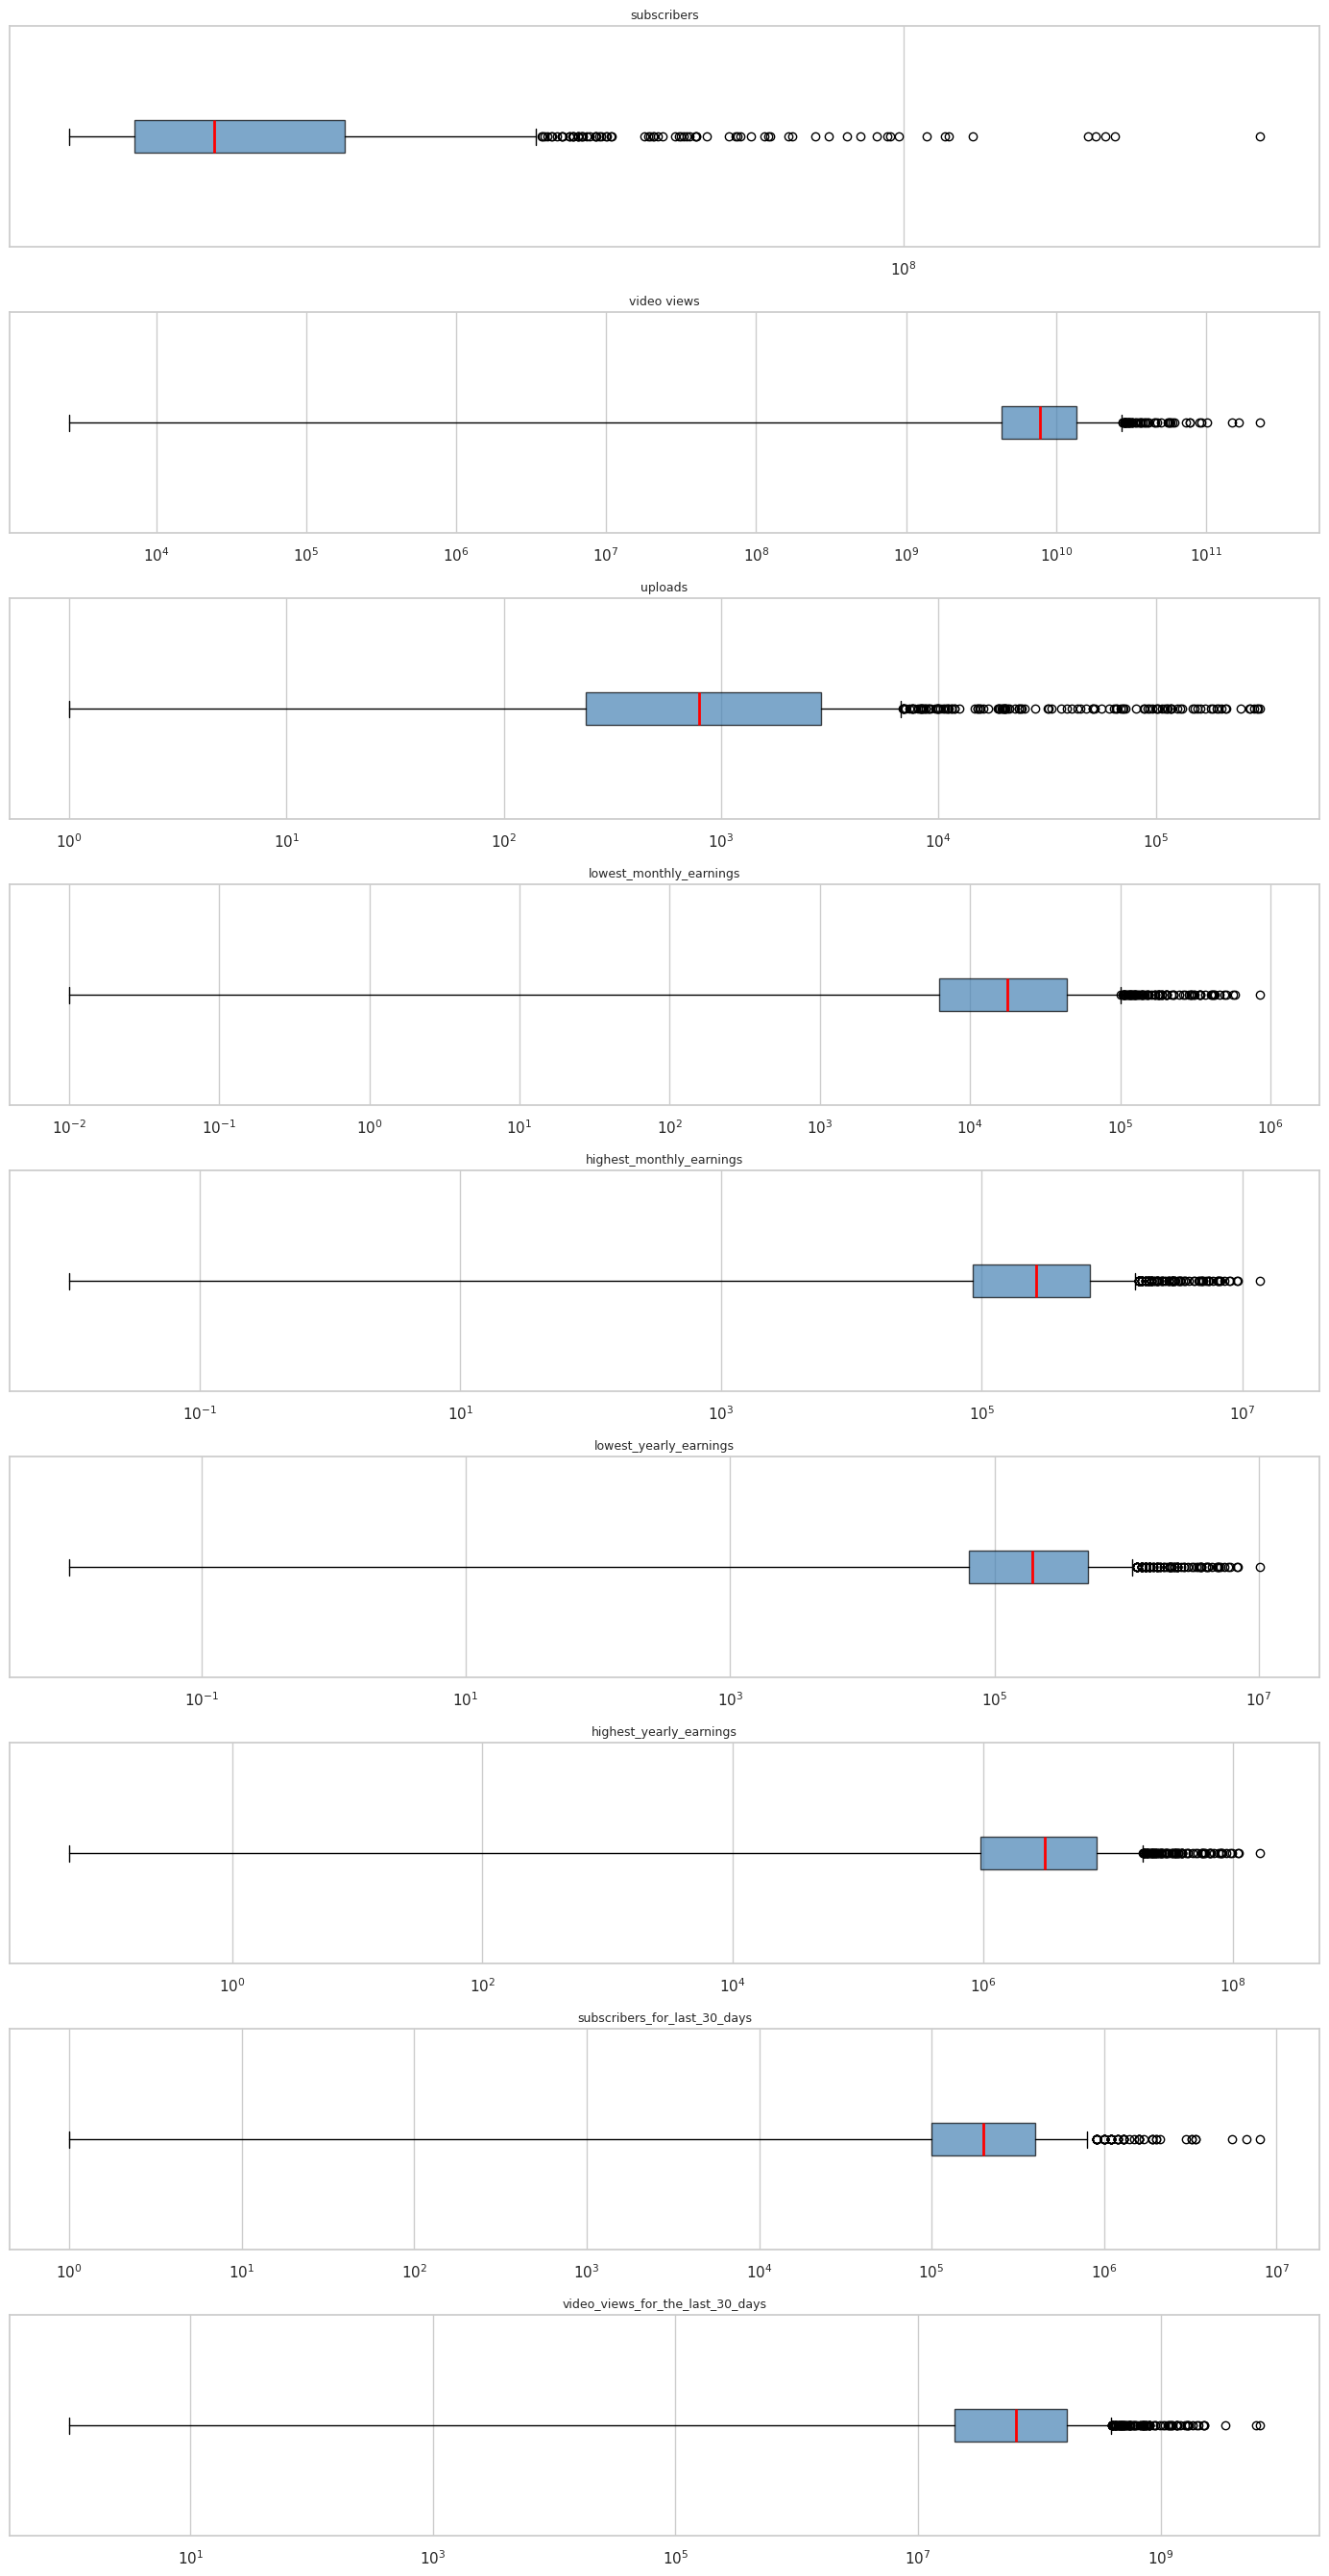

In [8]:
BOX_COLS = [
    'subscribers', 'video views', 'uploads',
    'lowest_monthly_earnings', 'highest_monthly_earnings',
    'lowest_yearly_earnings', 'highest_yearly_earnings',
    'subscribers_for_last_30_days', 'video_views_for_the_last_30_days',
]

fig, axes = plt.subplots(len(BOX_COLS), 1, figsize=(14, 3 * len(BOX_COLS)))

for i, col in enumerate(BOX_COLS):
    data = df[col].dropna()
    data = data[data > 0]
    axes[i].boxplot(data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_xscale('log')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

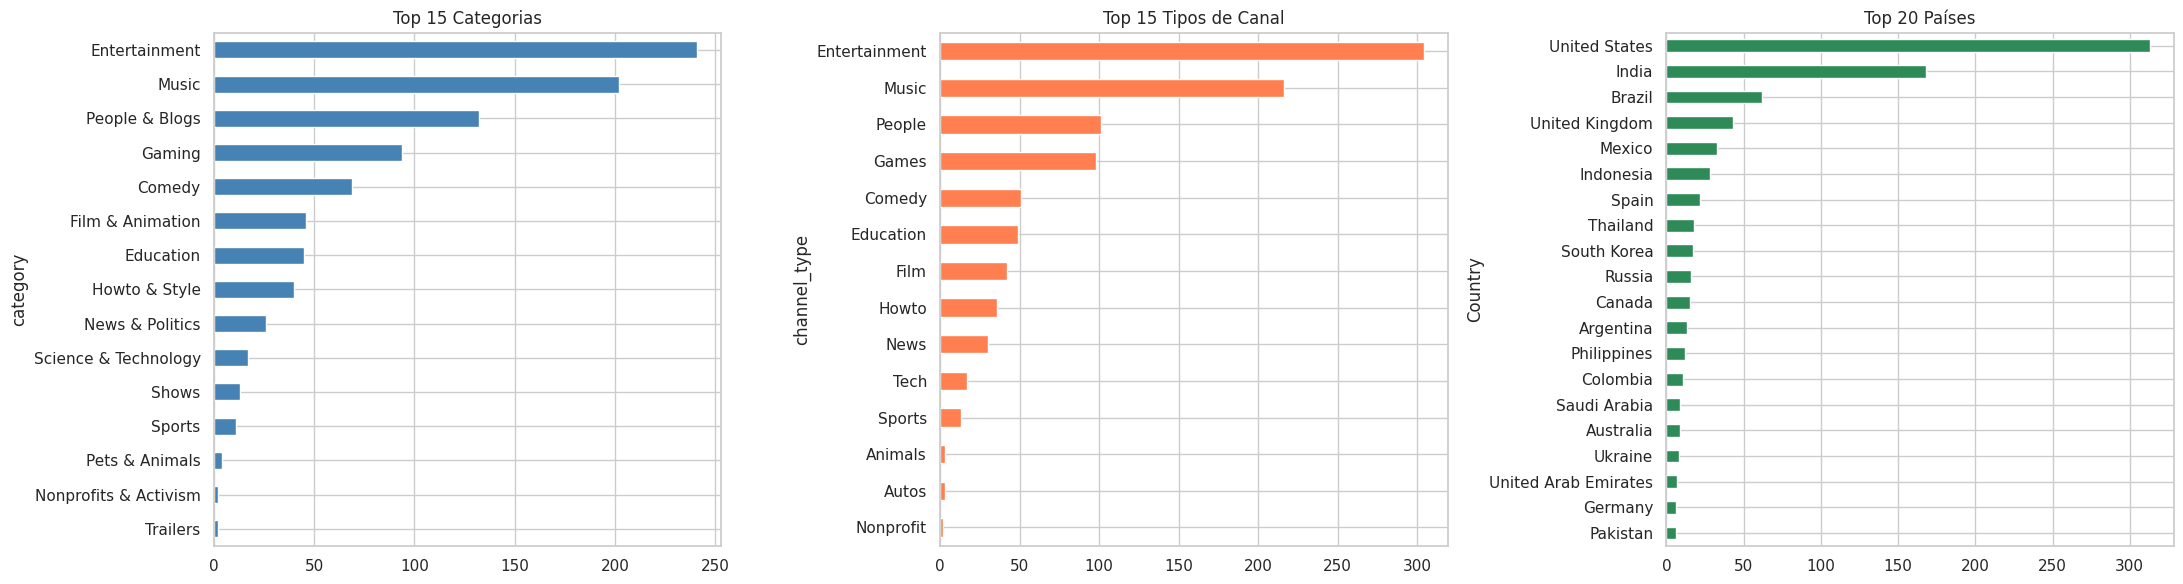

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

df['category'].value_counts().head(15).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Top 15 Categorias')

df['channel_type'].value_counts().head(15).sort_values().plot(
    kind='barh', ax=axes[1], color='coral'
)
axes[1].set_title('Top 15 Tipos de Canal')

df['Country'].dropna().value_counts().head(20).sort_values().plot(
    kind='barh', ax=axes[2], color='seagreen'
)
axes[2].set_title('Top 20 Países')

plt.tight_layout()
plt.show()

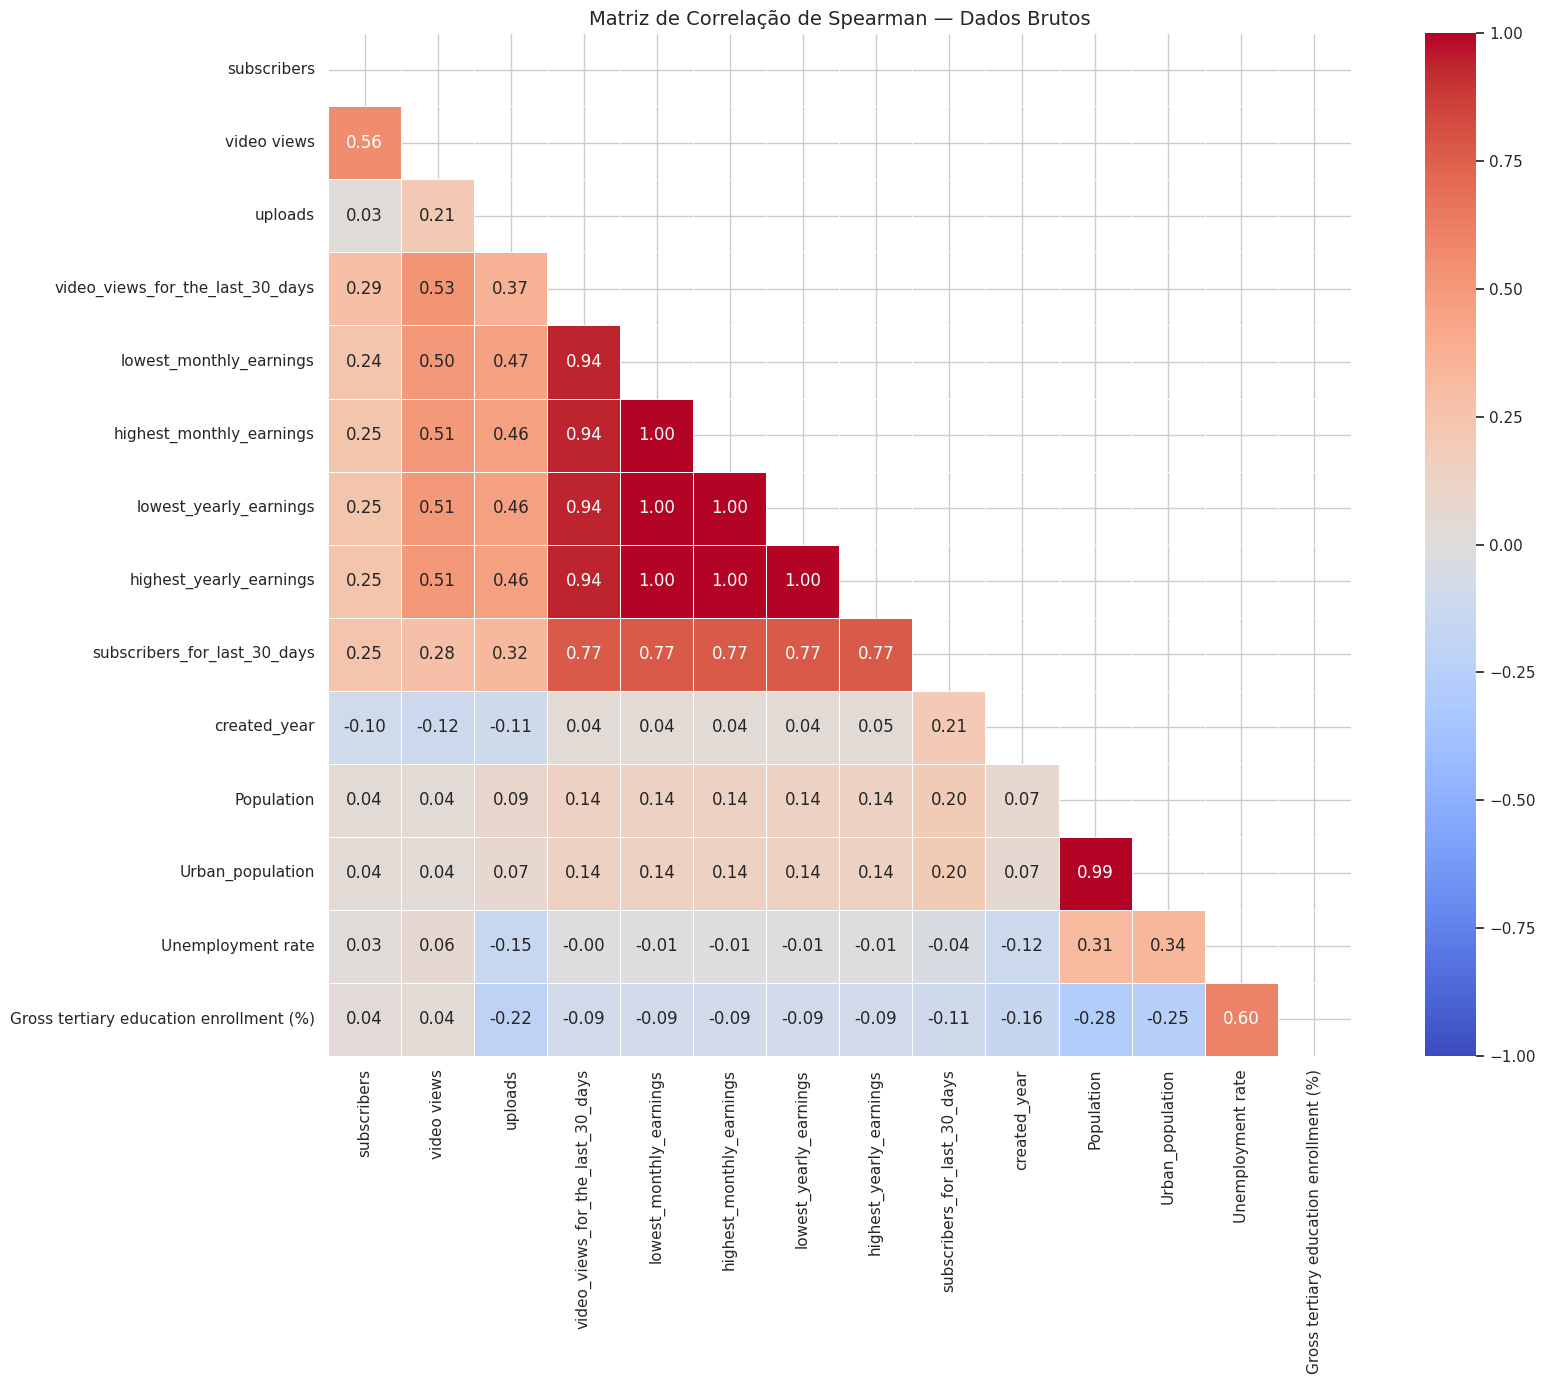

In [10]:
CORR_COLS = [
    'subscribers', 'video views', 'uploads',
    'video_views_for_the_last_30_days',
    'lowest_monthly_earnings', 'highest_monthly_earnings',
    'lowest_yearly_earnings', 'highest_yearly_earnings',
    'subscribers_for_last_30_days', 'created_year',
    'Population', 'Urban_population',
    'Unemployment rate', 'Gross tertiary education enrollment (%)',
]

spearman_corr = df[CORR_COLS].corr(method='spearman')
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
    square=True,
)
ax.set_title('Matriz de Correlação de Spearman — Dados Brutos', fontsize=14)
plt.tight_layout()
plt.show()

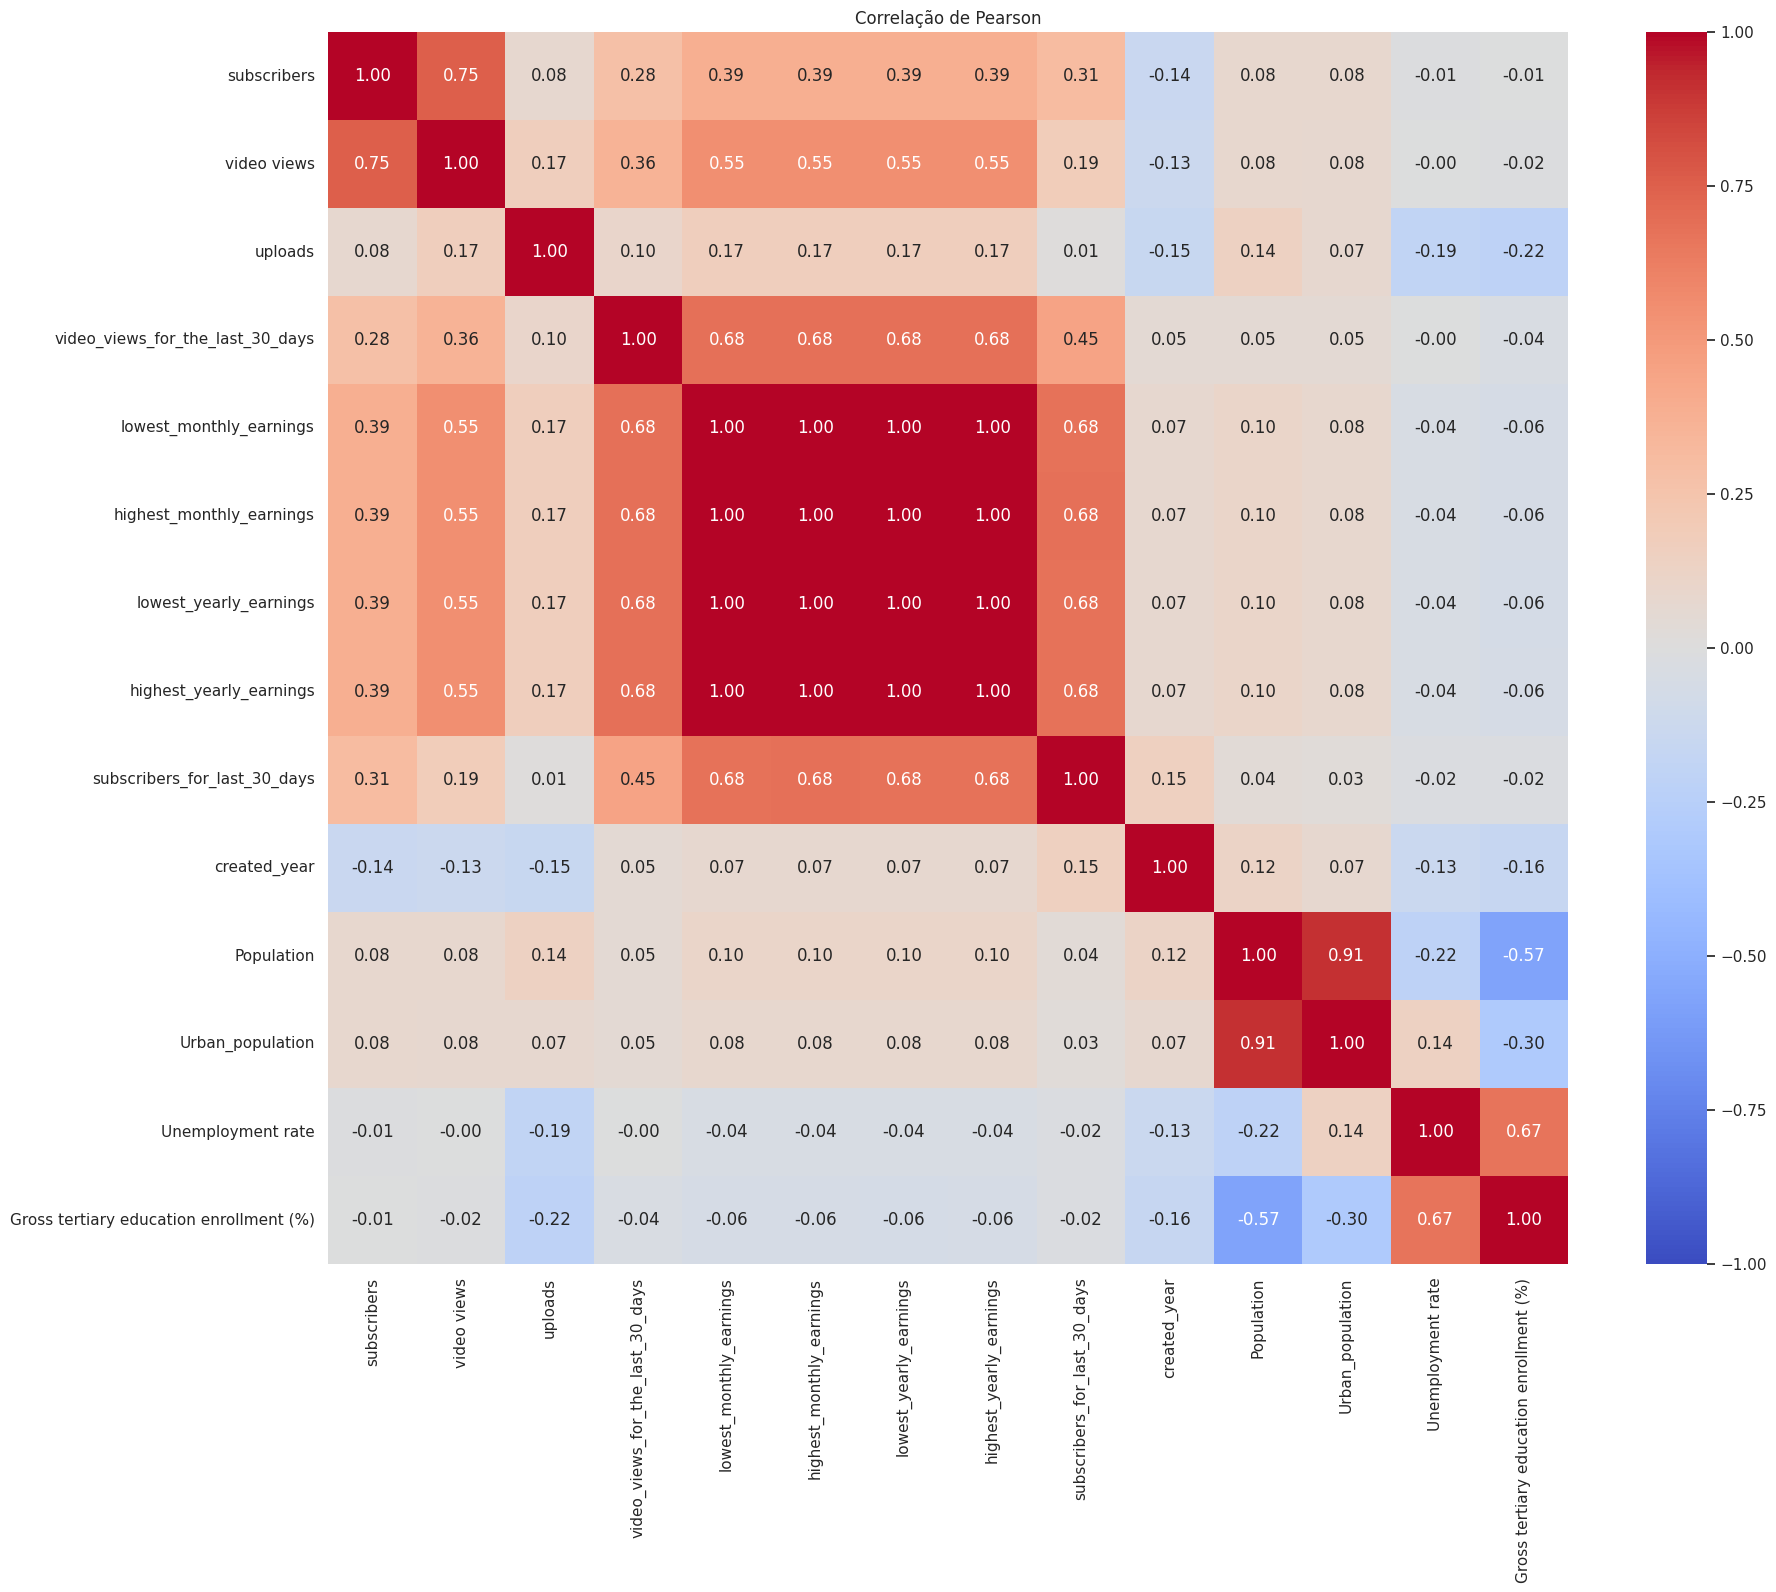

In [13]:
# Heatmap usando Correlação de Pearson (linear)
pearson_corr = (
    df[CORR_COLS]
    .corr(method='pearson')
)

plt.figure(figsize=(20,16))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Correlação de Pearson')
plt.show()

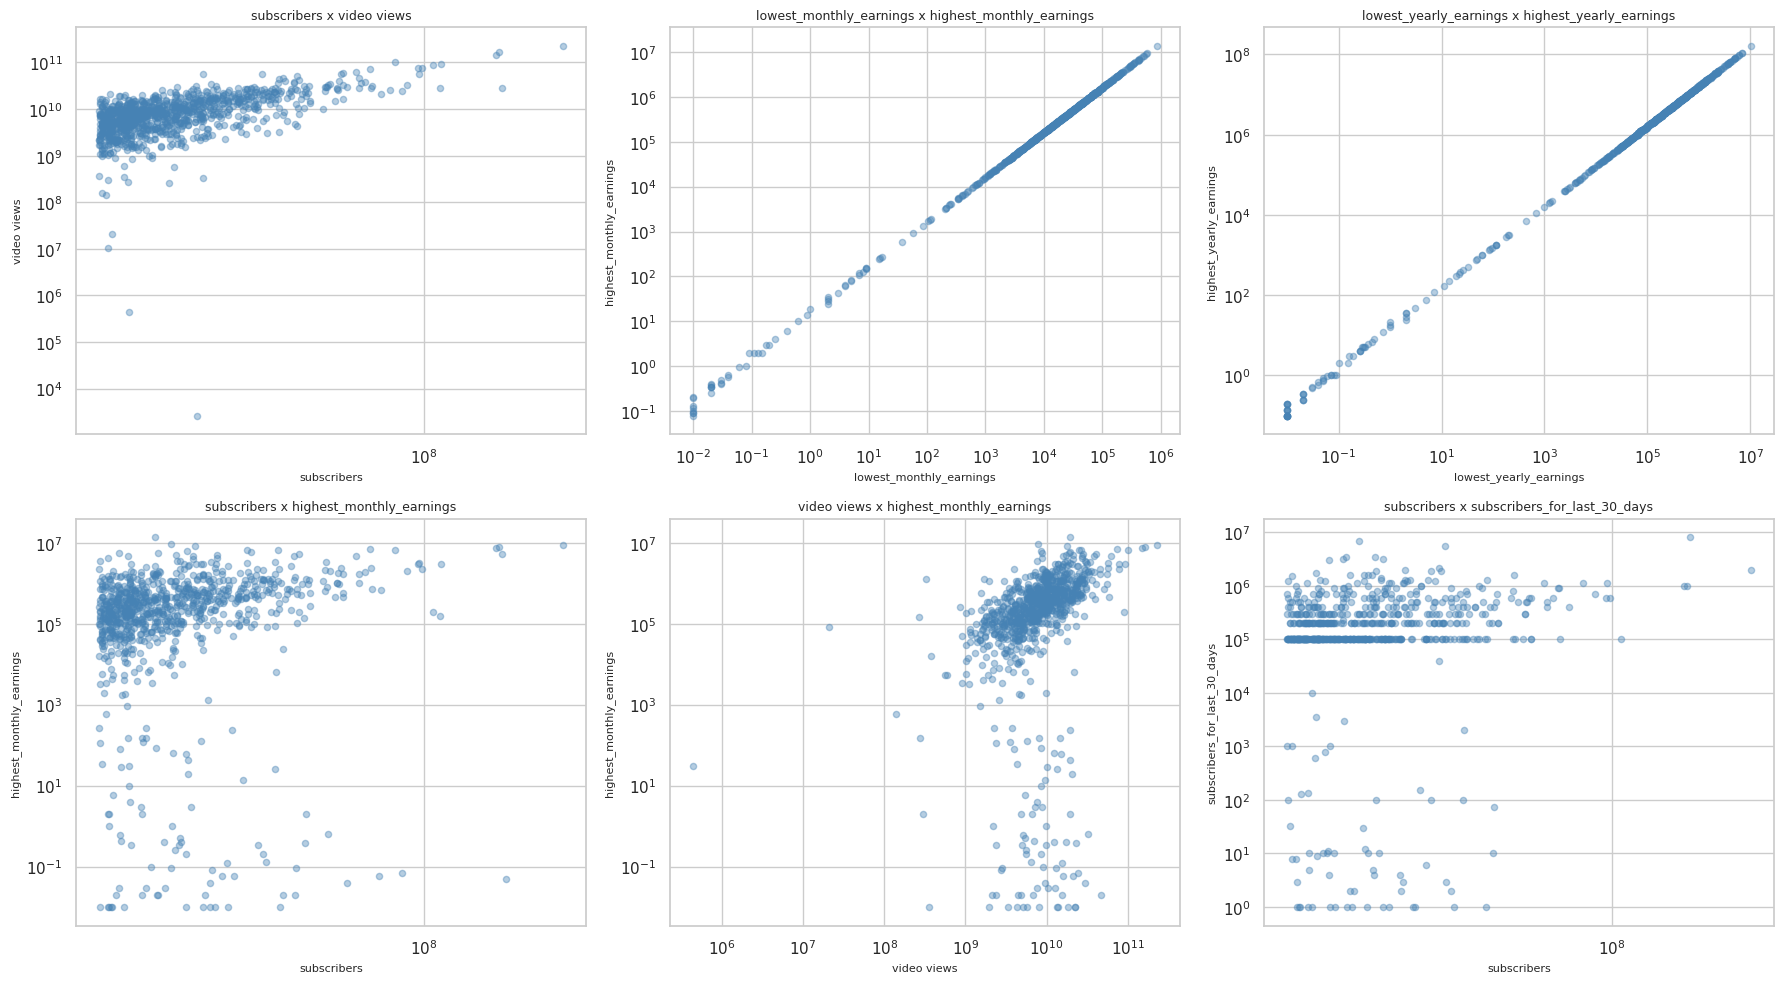

In [14]:
SCATTER_PAIRS = [
    ('subscribers', 'video views'),
    ('lowest_monthly_earnings', 'highest_monthly_earnings'),
    ('lowest_yearly_earnings', 'highest_yearly_earnings'),
    ('subscribers', 'highest_monthly_earnings'),
    ('video views', 'highest_monthly_earnings'),
    ('subscribers', 'subscribers_for_last_30_days'),
]

n_cols = 3
n_rows = -(-len(SCATTER_PAIRS) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, (x, y) in enumerate(SCATTER_PAIRS):
    data = df[[x, y]].dropna()
    data = data[(data[x] > 0) & (data[y] > 0)]
    axes[i].scatter(data[x], data[y], alpha=0.4, s=20, color='steelblue')
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_xlabel(x, fontsize=8)
    axes[i].set_ylabel(y, fontsize=8)
    axes[i].set_title(f'{x} x {y}', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Pré-processamento

### 3.1 Tratamento de Valores Faltantes

In [15]:
df_tratado = df.copy()

In [16]:
df_tratado['category'] = df_tratado['category'].fillna(df_tratado['category'].mode()[0])
df_tratado['channel_type'] = df_tratado['channel_type'].fillna(df_tratado['channel_type'].mode()[0])

In [17]:
# Atributos Country e Abbreviation possuem 122 valores faltantes, mas Latitude, Longitude, e outros possuem 123 valores ausentes. Verificar qual linha
# possui Country mas não tem valores para dados geográficos.
df_tratado[
    (df_tratado['Population'].isnull()) &
    (df_tratado['Country'].notnull())
][[
    'Youtuber',
    'Country',
    'Population',
    'Urban_population',
    'Unemployment rate',
    'Gross tertiary education enrollment (%)',
    'Latitude',
    'Longitude'
]]

,Youtuber,Country,Population,Urban_population,Unemployment rate,Gross tertiary education enrollment (%),Latitude,Longitude
663,Musas,Andorra,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Verificação de quantas linhas tem o país como Andorra
print((df['Country'] == 'Andorra').sum())

1


In [19]:
# Preenchimento dos valores ausentes do país Andorra com dados referentes a 2023 obtidos por pesquisa
andorra_vals = {
    'Population': 80856,
    'Urban_population': 70971,
    'Unemployment rate': 1.55,
    'Gross tertiary education enrollment (%)': 64.28,
    'Latitude': 42.5063,
    'Longitude': 1.5218,
}

for col, val in andorra_vals.items():
    df_tratado.loc[df_tratado['Country'] == 'Andorra', col] = val

In [20]:
df_tratado['Country'] = df_tratado['Country'].fillna('Unknown')
df_tratado['Abbreviation'] = df_tratado['Abbreviation'].fillna('UNK')

GEO_COLS = [
    'Population', 'Urban_population', 'Unemployment rate',
    'Gross tertiary education enrollment (%)', 'Latitude', 'Longitude',
]

for col in GEO_COLS:
    df_tratado[col] = df_tratado[col].fillna(df_tratado[col].median())

In [21]:
df_tratado['subscribers_for_last_30_days_missing'] = (
    df_tratado['subscribers_for_last_30_days'].isnull().astype(int)
)
df_tratado['subscribers_for_last_30_days'] = (
    df_tratado['subscribers_for_last_30_days']
    .fillna(df_tratado['subscribers_for_last_30_days'].median())
)

In [22]:
df_tratado['country_rank_missing'] = (
    df_tratado['country_rank'].isnull().astype(int)
)
df_tratado['country_rank'] = df_tratado['country_rank'].fillna(-1)

In [23]:
MEDIAN_COLS = [
    'video_views_rank', 'channel_type_rank',
    'video_views_for_the_last_30_days',
    'created_year', 'created_date',
]

for col in MEDIAN_COLS:
    df_tratado[col] = df_tratado[col].fillna(df_tratado[col].median())

df_tratado['created_month'] = df_tratado['created_month'].fillna(
    df_tratado['created_month'].mode()[0]
)

In [24]:
_rank_cols = {
    'rank', 'video_views_rank', 'country_rank', 'channel_type_rank',
    'created_year', 'created_date', 'country_rank_missing',
    'subscribers_for_last_30_days_missing', 'Latitude', 'Longitude',
}

_numeric = df_tratado.select_dtypes(include='number').columns
_outlier_cols = [c for c in _numeric if c not in _rank_cols]

rows = []
for col in _outlier_cols:
    Q1, Q3 = df_tratado[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n = ((df_tratado[col] < Q1 - 1.5 * IQR) | (df_tratado[col] > Q3 + 1.5 * IQR)).sum()
    rows.append({'coluna': col, 'outliers': n, 'percentual': f'{n / len(df_tratado) * 100:.1f}%'})

pd.DataFrame(rows).sort_values('outliers', ascending=False).reset_index(drop=True)

,coluna,outliers,percentual
0,subscribers_for_last_30_days,177,17.8%
1,Population,169,17.0%
2,uploads,132,13.3%
3,video_views_for_the_last_30_days,106,10.7%
4,lowest_yearly_earnings,102,10.3%
5,highest_yearly_earnings,99,9.9%
6,highest_monthly_earnings,99,9.9%
7,lowest_monthly_earnings,99,9.9%
8,subscribers,76,7.6%
9,video views,52,5.2%


### 3.2 Feature Engineering

In [25]:
REFERENCE_YEAR = 2023

df_tratado['channel_age'] = REFERENCE_YEAR - df_tratado['created_year'].astype(int)

df_tratado['views_per_subscriber'] = (
    df_tratado['video views'] / df_tratado['subscribers']
)

df_tratado['views_per_upload'] = np.where(
    df_tratado['uploads'] > 0,
    df_tratado['video views'] / df_tratado['uploads'],
    0
)

df_tratado['earnings_spread'] = (
    df_tratado['highest_yearly_earnings'] - df_tratado['lowest_yearly_earnings']
)

df_tratado['urban_ratio'] = (
    df_tratado['Urban_population'] / df_tratado['Population']
)

df_tratado['subscriber_growth_rate'] = (
    df_tratado['subscribers_for_last_30_days'] / df_tratado['subscribers']
)

df_tratado[[
    'channel_age', 'views_per_subscriber', 'views_per_upload',
    'earnings_spread', 'urban_ratio', 'subscriber_growth_rate'
]].describe()

,channel_age,views_per_subscriber,views_per_upload,earnings_spread,urban_ratio,subscriber_growth_rate
count,995.000000,995.000000,9.950000e+02,9.950000e+02,995.000000,9.950000e+02
mean,10.367839,458.258976,4.147036e+08,6.639557e+06,0.720217,1.433372e-02
std,4.501215,283.059314,2.343111e+09,1.293588e+07,0.194326,2.087672e-02
min,1.000000,0.000000,0.000000e+00,0.000000e+00,0.175738,2.247191e-08
25%,7.000000,246.172887,1.890374e+06,4.891000e+05,0.694730,6.211180e-03
50%,10.000000,422.074109,7.051635e+06,2.434600e+06,0.824590,1.000000e-02
75%,14.000000,612.872811,2.613198e+07,6.845250e+06,0.824590,1.477583e-02
max,53.000000,2328.053424,3.068634e+10,1.532000e+08,1.000000,3.418367e-01


### 3.4 Remoção de Features Redundantes

In [26]:
_num = df_tratado.select_dtypes('number').drop(
    columns=['country_rank_missing', 'subscribers_for_last_30_days_missing']
)
_upper = _num.corr(method='spearman').abs()
_upper = _upper.where(np.triu(np.ones_like(_upper, dtype=bool), k=1))

high_corr_pairs = (
    _upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'spearman_abs'})
    .query('spearman_abs >= 0.97')
    .sort_values('spearman_abs', ascending=False)
    .reset_index(drop=True)
)
display(high_corr_pairs)

DROP_COLS = [
    'rank',
    'video_views_rank',
    'channel_type_rank',
    'Abbreviation',
    'lowest_yearly_earnings',
    'highest_yearly_earnings',
    'lowest_monthly_earnings',
    'created_year',
    'created_month',
    'created_date',
    'Urban_population',
    'Latitude',
    'Longitude',
]

df_tratado = df_tratado.drop(columns=DROP_COLS)
print(f'Shape após remoção: {df_tratado.shape}')
print(f'Colunas removidas ({len(DROP_COLS)}): {DROP_COLS}')

,feature_1,feature_2,spearman_abs
0,created_year,channel_age,1.000000
1,highest_monthly_earnings,lowest_yearly_earnings,0.999989
2,highest_yearly_earnings,earnings_spread,0.999977
3,rank,subscribers,0.999960
4,lowest_yearly_earnings,highest_yearly_earnings,0.999866
5,highest_monthly_earnings,highest_yearly_earnings,0.999862
6,lowest_yearly_earnings,earnings_spread,0.999797
7,highest_monthly_earnings,earnings_spread,0.999794
8,lowest_monthly_earnings,lowest_yearly_earnings,0.999521
9,lowest_monthly_earnings,highest_monthly_earnings,0.999515


Shape após remoção: (995, 23)
Colunas removidas (13): ['rank', 'video_views_rank', 'channel_type_rank', 'Abbreviation', 'lowest_yearly_earnings', 'highest_yearly_earnings', 'lowest_monthly_earnings', 'created_year', 'created_month', 'created_date', 'Urban_population', 'Latitude', 'Longitude']


### 3.5 Transformações

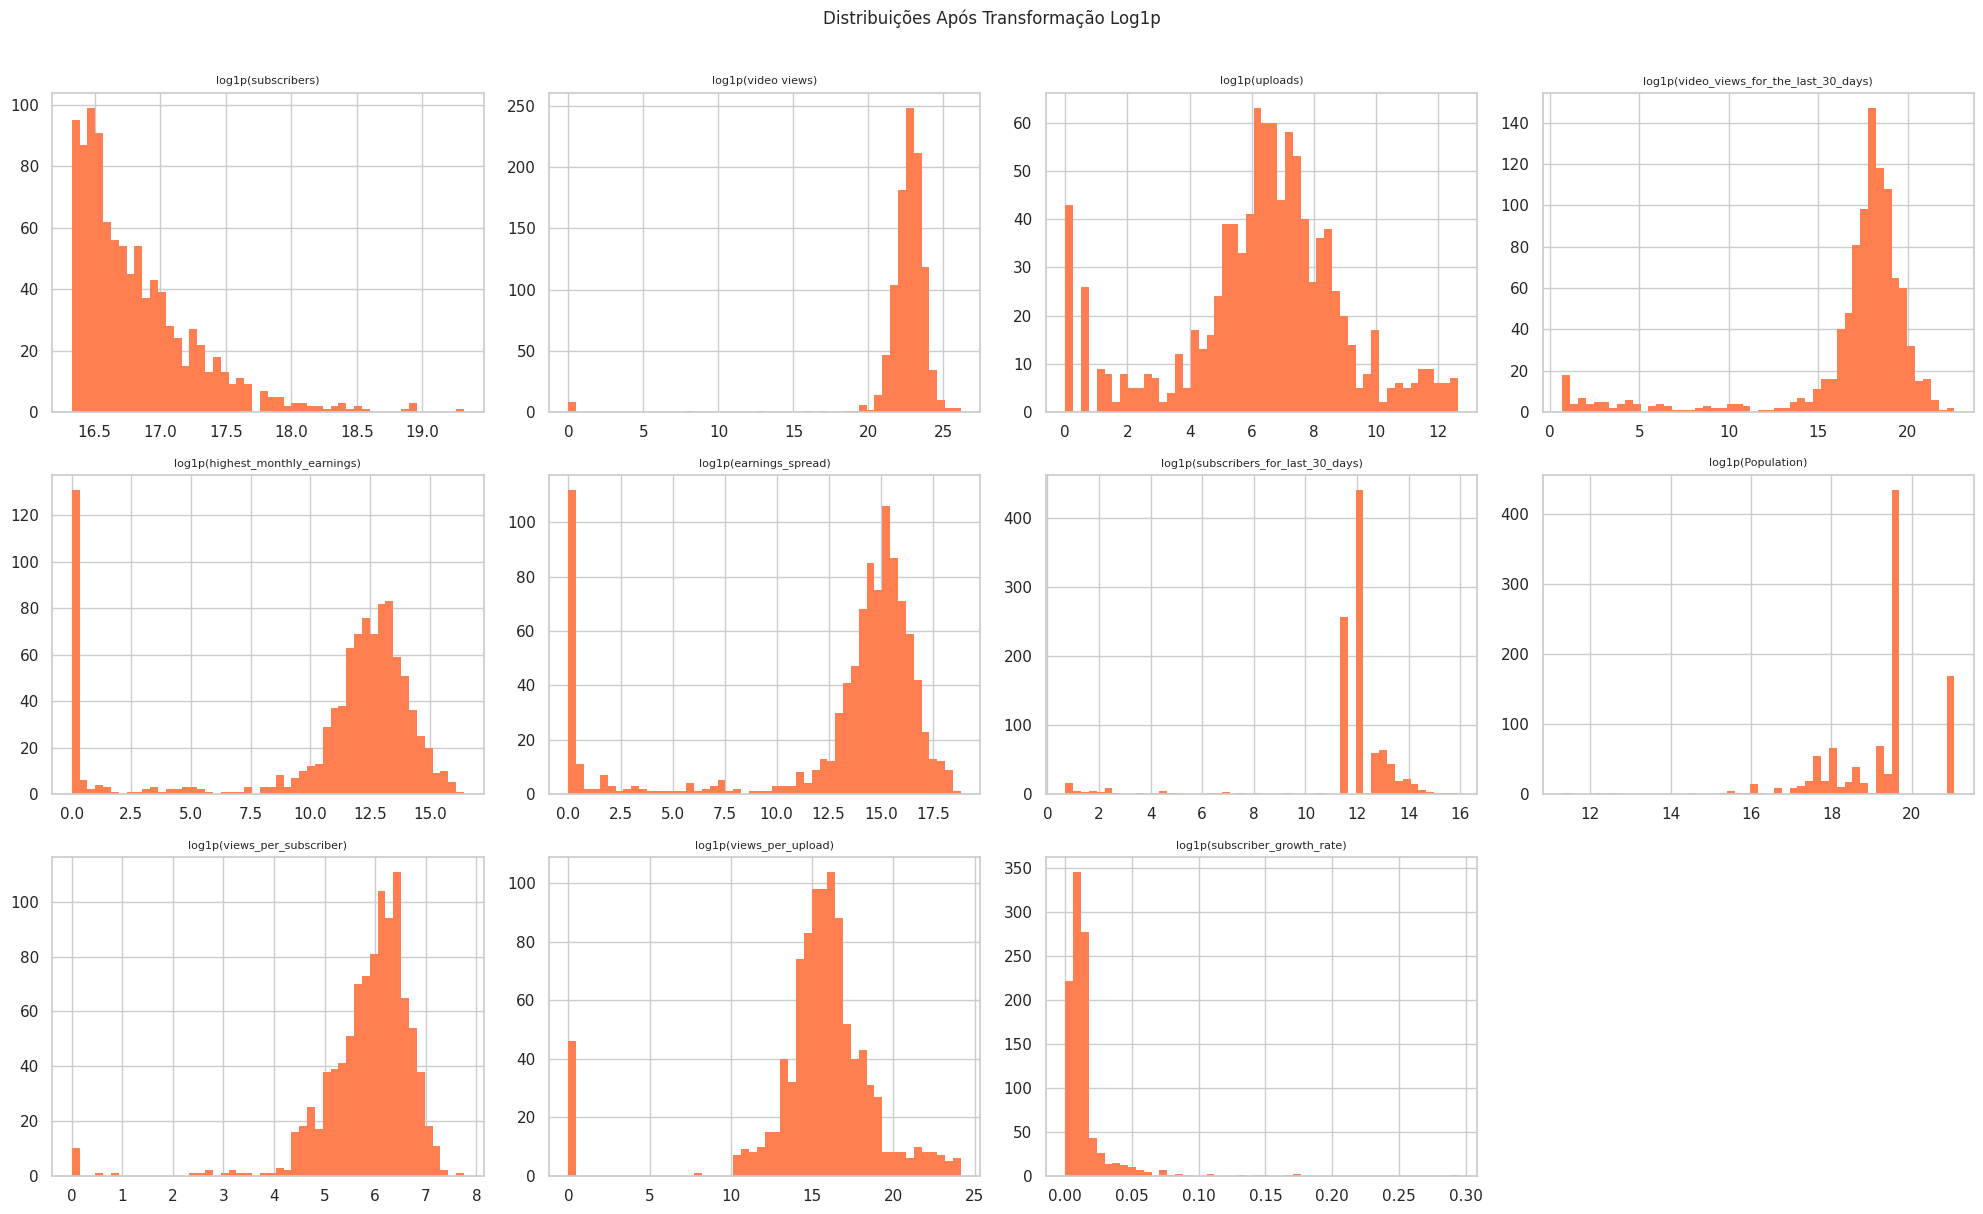

In [27]:
LOG_COLS = [
    'subscribers', 'video views', 'uploads',
    'video_views_for_the_last_30_days',
    'highest_monthly_earnings', 'earnings_spread',
    'subscribers_for_last_30_days', 'Population',
    'views_per_subscriber', 'views_per_upload',
    'subscriber_growth_rate',
]

df_tratado[LOG_COLS] = df_tratado[LOG_COLS].apply(np.log1p)

n_cols = 4
n_rows = -(-len(LOG_COLS) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(LOG_COLS):
    axes[i].hist(df_tratado[col], bins=50, color='coral', edgecolor='none')
    axes[i].set_title(f'log1p({col})', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuições Após Transformação Log1p', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

### 3.3 Normalização

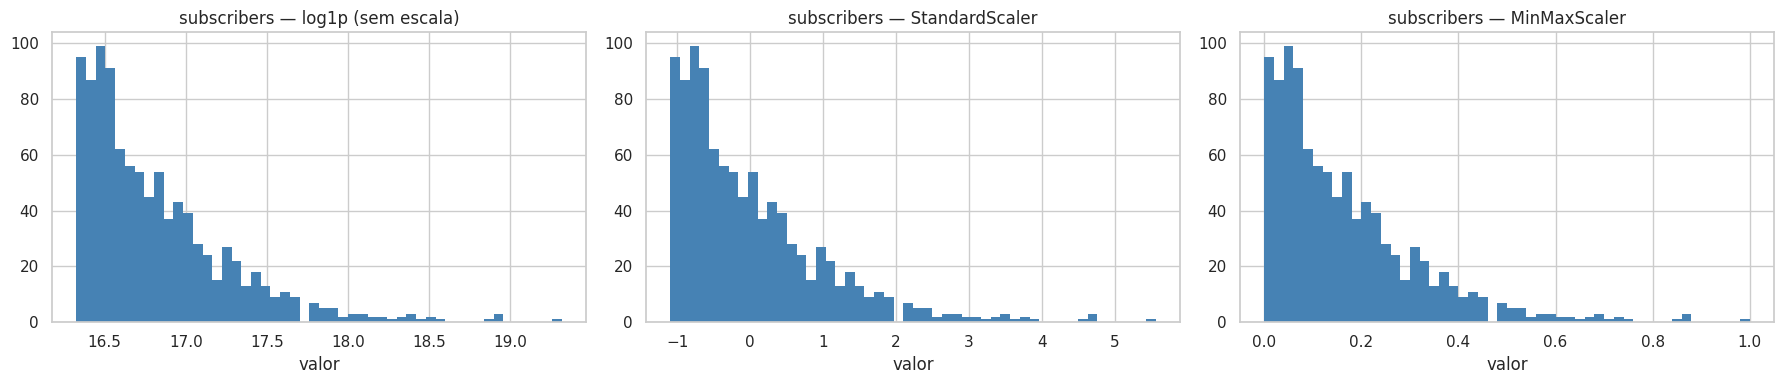

In [30]:
SCALE_COLS = [
    'subscribers', 'video views', 'uploads',
    'video_views_for_the_last_30_days',
    'highest_monthly_earnings', 'earnings_spread',
    'subscribers_for_last_30_days', 'Population',
    'channel_age', 'views_per_subscriber', 'views_per_upload',
    'urban_ratio', 'subscriber_growth_rate',
]

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

df_std = df_tratado.copy()
df_mm = df_tratado.copy()

df_std[SCALE_COLS] = scaler_std.fit_transform(df_tratado[SCALE_COLS])
df_mm[SCALE_COLS] = scaler_mm.fit_transform(df_tratado[SCALE_COLS])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (label, data) in zip(axes, [
    ('log1p (sem escala)', df_tratado['subscribers']),
    ('StandardScaler', df_std['subscribers']),
    ('MinMaxScaler', df_mm['subscribers']),
]):
    ax.hist(data, bins=50, color='steelblue', edgecolor='none')
    ax.set_title(f'subscribers — {label}')
    ax.set_xlabel('valor')

plt.tight_layout()
plt.show()

In [31]:
print(f'Shape final: {df_tratado.shape}')
print(f'Valores nulos: {df_tratado.isnull().sum().sum()}')
print(f'\nColunas adicionadas: {[c for c in df_tratado.columns if c not in df.columns]}')

Shape final: (995, 23)
Valores nulos: 0

Colunas adicionadas: ['subscribers_for_last_30_days_missing', 'country_rank_missing', 'channel_age', 'views_per_subscriber', 'views_per_upload', 'earnings_spread', 'urban_ratio', 'subscriber_growth_rate']


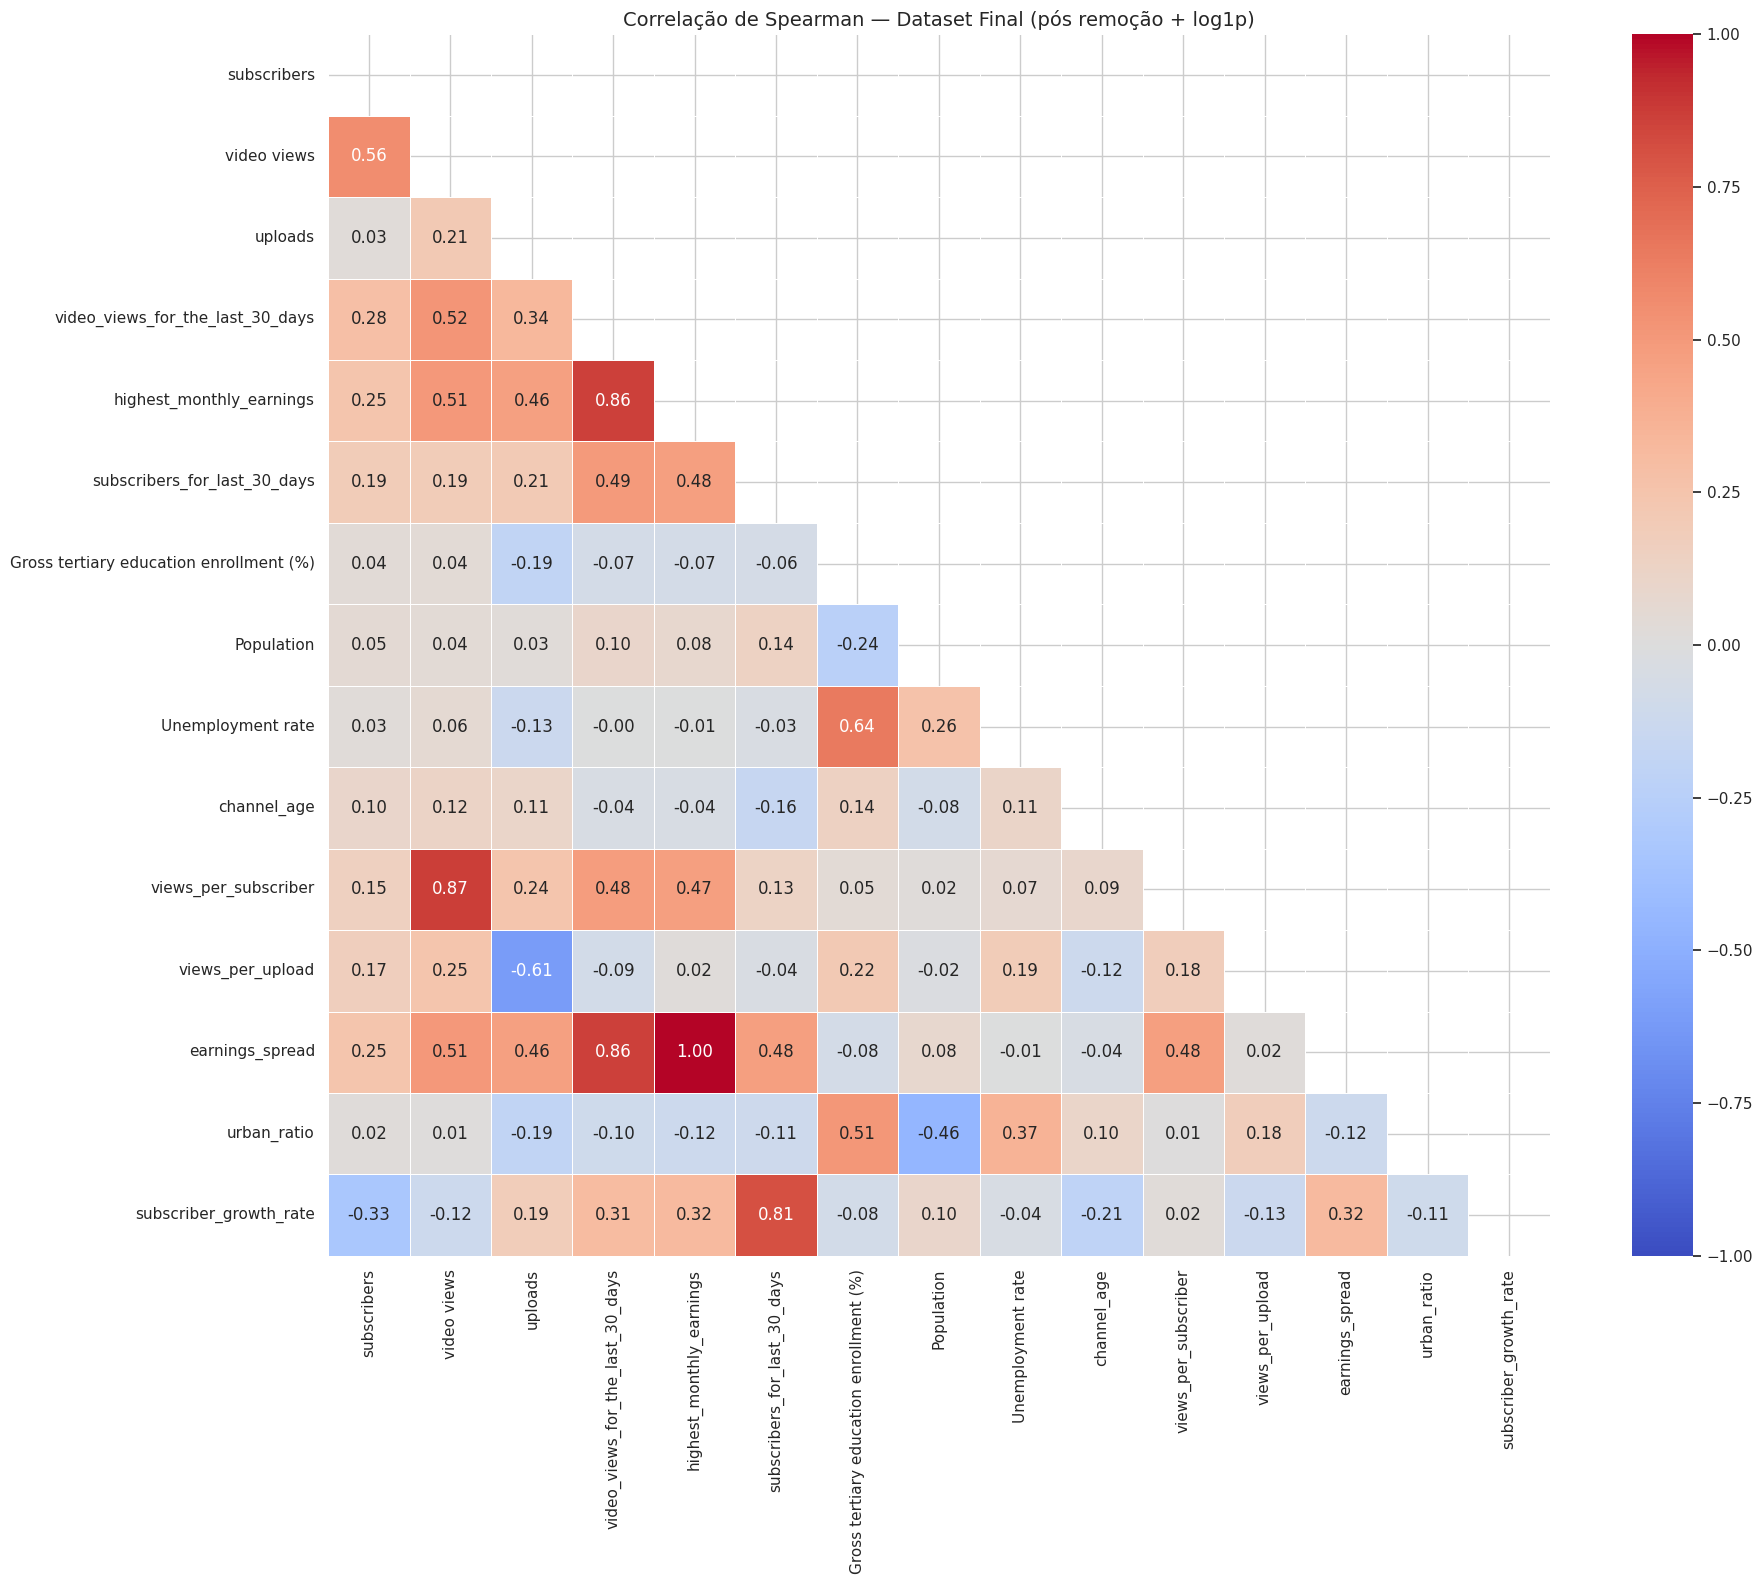

In [32]:
FINAL_NUM_COLS = [
    c for c in df_tratado.select_dtypes('number').columns
    if c not in {'country_rank', 'country_rank_missing', 'subscribers_for_last_30_days_missing'}
]

spearman_final = df_tratado[FINAL_NUM_COLS].corr(method='spearman')
mask_final = np.triu(np.ones_like(spearman_final, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    spearman_final,
    mask=mask_final,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
    square=True,
)
ax.set_title('Correlação de Spearman — Dataset Final (pós remoção + log1p)', fontsize=14)
plt.tight_layout()
plt.show()

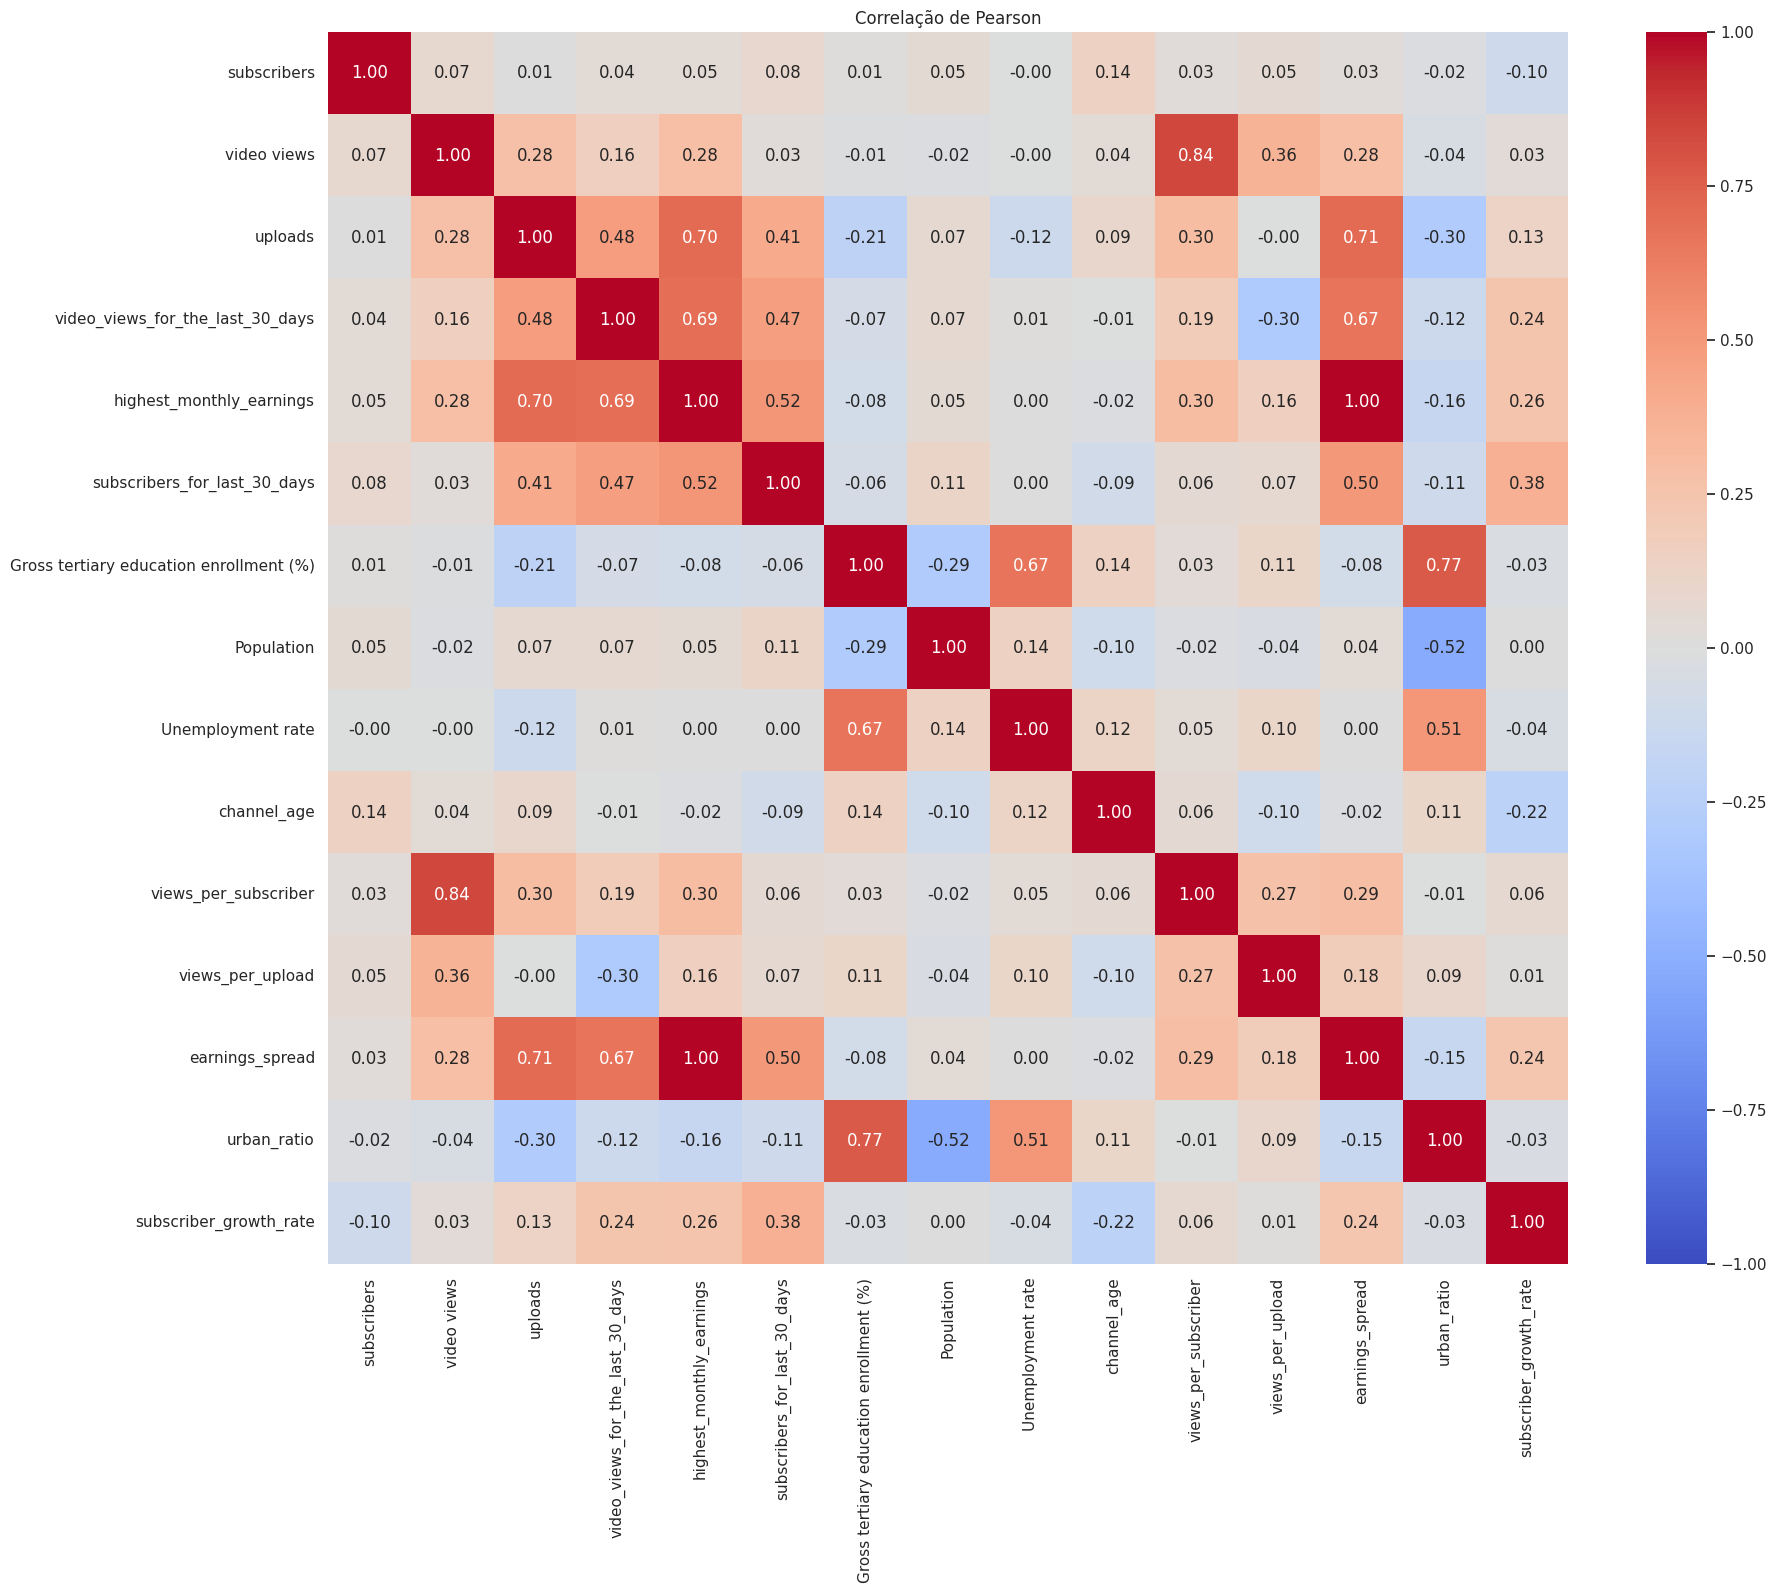

In [34]:
# Heatmap para Correlação de Pearson (relações lineares)
pearson_corr = (
    df_tratado[FINAL_NUM_COLS]
    .corr(method='pearson')
)

plt.figure(figsize=(20,16))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Correlação de Pearson')
plt.show()

In [36]:
# Salvar os DataFrames
df_tratado.to_csv('df_tratado.csv', index=False)
df_std.to_csv('df_std.csv', index=False)
df_mm.to_csv('df_mm.csv', index=False)

# Download automático
files.download('df_tratado.csv')
files.download('df_std.csv')
files.download('df_mm.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Resumo do Pré-processamento

### Dados Limpos

| Coluna | Faltantes | Estratégia | Justificativa |
|--------|-----------|-----------|---------------|
| `category` | 46 | Moda | Categórica; classe dominante "Entertainment" |
| `channel_type` | 30 | Moda | Baixa faltância; categórica |
| `Country` / `Abbreviation` | 122 | `'Unknown'` / `'UNK'` | Sem dado confiável; sentinela preserva o grupo |
| Andorra (geo/demo) | 1 | Lookup manual | Único caso; dados públicos disponíveis |
| `Population`, `Urban_population`, `Unemployment rate`, `Gross tertiary education (%)`, `Latitude`, `Longitude` | 122 | Mediana | Distribuições assimétricas; mediana robusta a outliers |
| `subscribers_for_last_30_days` | 337 (34%) | Indicador binário + Mediana | Alta faltância potencialmente informativa (canais inativos); `subscribers_for_last_30_days_missing` criado antes da imputação |
| `country_rank` | 116 | Indicador binário + Sentinela −1 | Ordinal; −1 inequívoco como "sem rank"; `country_rank_missing` criado antes da imputação |
| `video_views_rank`, `channel_type_rank`, `video_views_for_the_last_30_days`, `created_year`, `created_date` | < 60 | Mediana | Baixa faltância; distribuições assimétricas |
| `created_month` | 5 | Moda | Categórica (nome do mês) |

### Outliers

Outliers documentados via IQR mas **preservados**. Os registros representam canais reais (T-Series: 245M subs, MrBeast: 166M, Cocomelon: 162M). Remoção enviesaria qualquer modelo em direção a canais de médio porte.

### Features Engineered

| Feature | Fórmula | Interpretação |
|---------|---------|---------------|
| `channel_age` | `2023 − created_year` | Maturidade do canal em anos |
| `views_per_subscriber` | `video views ÷ subscribers` | Eficiência de consumo por seguidor |
| `views_per_upload` | `video views ÷ uploads` (0 se uploads=0) | Performance média por vídeo |
| `earnings_spread` | `highest_yearly_earnings − lowest_yearly_earnings` | Volatilidade de monetização |
| `urban_ratio` | `Urban_population ÷ Population` | Taxa de urbanização do país |
| `subscriber_growth_rate` | `subscribers_for_last_30_days ÷ subscribers` | Crescimento mensal relativo ao tamanho do canal |

### Normalização

Duas cópias normalizadas criadas para `SCALE_COLS` (16 colunas contínuas):

- **`df_std`** — StandardScaler: média zero, variância unitária. Preferível para PCA, SVM, regressão logística.
- **`df_mm`** — MinMaxScaler: intervalo [0, 1]. Preferível para KNN, redes neurais.

`df_tratado` permanece como DataFrame canônico não normalizado para todas as análises subsequentes.

### Shape Final

`df_tratado`: **995 linhas × 23 colunas**